In [65]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df.isnull().any()

RowNumber          False
CustomerId         False
Surname            False
CreditScore        False
Geography          False
Gender             False
Age                False
Tenure             False
Balance            False
NumOfProducts      False
HasCrCard          False
IsActiveMember     False
EstimatedSalary    False
Exited             False
dtype: bool

In [13]:
df_new=df.iloc[:,3:13]

In [14]:
df_new.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [50]:
#Feature Engineering
x = pd.get_dummies(df_new,columns=['Geography','Gender'],drop_first=True)

In [51]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [42]:
y=df.iloc[:,13]

In [43]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [66]:
#Train Test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [67]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [69]:
x_train_tr=scaler.fit_transform(x_train)
x_test_tr=scaler.transform(x_test)

In [70]:
x_train_tr

array([[ 1.27754581, -1.23264342, -0.012743  , ..., -0.58408625,
        -0.57138416, -1.0862028 ],
       [-0.49959477,  0.28410615,  0.33282985, ...,  1.71207591,
        -0.57138416, -1.0862028 ],
       [ 0.67827747, -0.09508124, -1.39503438, ..., -0.58408625,
        -0.57138416, -1.0862028 ],
       ...,
       [ 2.06279398, -0.28467494, -0.70388869, ..., -0.58408625,
        -0.57138416,  0.9206384 ],
       [-1.02653762,  1.42166833, -0.012743  , ...,  1.71207591,
        -0.57138416,  0.9206384 ],
       [ 0.03768029, -1.04304972,  0.67840269, ..., -0.58408625,
        -0.57138416, -1.0862028 ]], shape=(8000, 11))

In [71]:
x_test_tr

array([[ 8.33260665e-01, -9.50812388e-02,  1.71512123e+00, ...,
        -5.84086250e-01, -5.71384156e-01, -1.08620280e+00],
       [-5.53096261e-02,  1.89309306e-01, -1.04946154e+00, ...,
         1.71207591e+00, -5.71384156e-01, -1.08620280e+00],
       [-3.34279369e-01,  1.61126203e+00,  6.78402693e-01, ...,
        -5.84086250e-01, -5.71384156e-01,  9.20638397e-01],
       ...,
       [ 8.74589516e-01, -9.50812388e-02, -1.39503438e+00, ...,
        -5.84086250e-01, -5.71384156e-01, -1.08620280e+00],
       [ 3.88975520e-01, -2.84390545e-04, -1.74060723e+00, ...,
        -5.84086250e-01, -5.71384156e-01, -1.08620280e+00],
       [ 7.29938538e-01,  6.63293547e-01, -1.39503438e+00, ...,
        -5.84086250e-01, -5.71384156e-01,  9.20638397e-01]],
      shape=(2000, 11))

In [76]:
# Importing ANN libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU
from tensorflow.keras.layers import Dropout

In [77]:
# Initialize ANN
classifier = Sequential()

In [82]:
x_train_tr.shape

(8000, 11)

In [83]:
# Adding Input layer
classifier.add(Dense(units=11, activation='relu'))

In [84]:
# Adding First Hidden Layer
classifier.add(Dense(units=7,activation='relu'))

In [85]:
# Adding second Hidden Layer
classifier.add(Dense(units=6,activation='relu'))

In [86]:
# Adding the Output layer
classifier.add(Dense(1,activation='sigmoid'))

In [87]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [88]:
#Trian model
classifier.fit(x_train_tr,y_train,validation_split=0.33,batch_size=10,epochs=1000)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7852 - loss: 0.5108 - val_accuracy: 0.8141 - val_loss: 0.4369
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8145 - loss: 0.4328 - val_accuracy: 0.8368 - val_loss: 0.3985
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8212 - loss: 0.4086 - val_accuracy: 0.8338 - val_loss: 0.3839
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8272 - loss: 0.3928 - val_accuracy: 0.8421 - val_loss: 0.3756
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8378 - loss: 0.3798 - val_accuracy: 0.8482 - val_loss: 0.3627
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8472 - loss: 0.3685 - val_accuracy: 0.8523 - val_loss: 0.3569
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8520 - loss: 0.3590 - val_accuracy: 0.8595 - val_loss: 0.3481
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8552 - loss: 0.3533 - 

KeyboardInterrupt: 

In [89]:
# after sometime accuracy and val_loss will become stagnant
# use Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10
)

In [92]:
#Add early stopping to model
history=classifier.fit(
    x_train_tr,
    y_train,
    validation_split=0.33,
    batch_size=10,
    epochs=1000,
    callbacks=[early_stop]
)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8625 - loss: 0.3228 - val_accuracy: 0.8626 - val_loss: 0.3405
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8606 - loss: 0.3232 - val_accuracy: 0.8671 - val_loss: 0.3397
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8621 - loss: 0.3219 - val_accuracy: 0.8641 - val_loss: 0.3396
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8578 - loss: 0.3225 - val_accuracy: 0.8622 - val_loss: 0.3397
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8614 - loss: 0.3217 - val_accuracy: 0.8629 - val_loss: 0.3385
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8619 - loss: 0.3211 - val_accuracy: 0.8626 - val_loss: 0.3451
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8612 - loss: 0.3207 - val_accuracy: 0.8610 - val_loss: 0.3412
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8617 - loss: 0.3209 - 

In [94]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

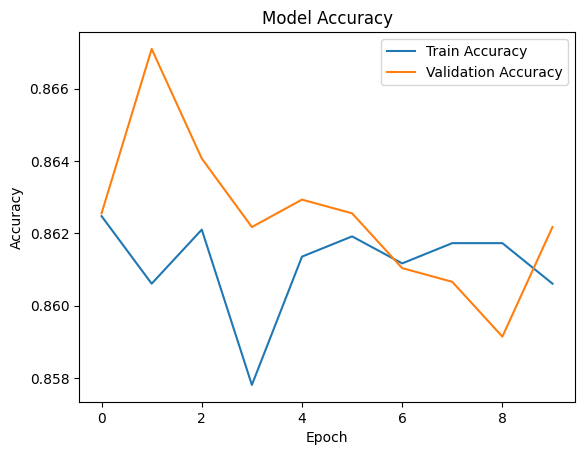

In [95]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

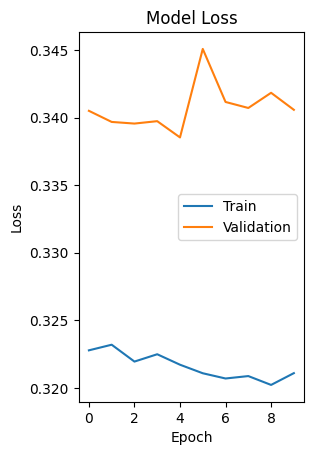

In [96]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [97]:
y_pre = classifier.predict(x_test_tr)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [99]:
y_pre = (y_pre >= 0.5)

In [101]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pre)
cm

array([[1562,   55],
       [ 224,  159]])

In [103]:
# calculate accuracy

from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test, y_pre)

In [104]:
ac

0.8605

In [107]:
#Get the weights

classifier.get_weights()

[array([[ 0.3135578 ,  0.17989385,  0.11095332, -0.3789875 ,  0.01422329,
          0.08201896,  0.10727309,  0.3795468 , -0.04844538,  0.5757097 ,
          0.07515285],
        [ 1.1132013 , -0.8610445 ,  0.02046486,  0.05008333, -0.59565526,
         -0.14466363,  0.17461614, -0.51782596,  0.6728892 ,  0.04960138,
         -0.8489017 ],
        [-0.4513028 ,  0.0949134 , -0.09788112,  0.13333972,  0.00237229,
         -0.14994347, -0.14920157, -0.35225308,  0.38101256, -0.2896813 ,
         -0.16134833],
        [ 0.20078157, -0.7103    , -0.02684789, -0.8128506 ,  0.14469902,
          0.10868174,  0.5033935 , -0.14900663, -0.17650458,  0.15978093,
          0.7943107 ],
        [ 0.04535249, -0.13388869, -1.3052347 , -0.53219926,  0.04530149,
         -0.4548017 ,  1.2342576 , -0.05089622,  0.16624886,  0.34837842,
         -0.02644644],
        [-0.18570675, -0.15841009,  0.14501193,  0.06826052, -0.19784024,
         -0.25321677,  0.12547605,  0.46090975,  0.70452565,  0.2956732